In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter  # to print to tensorboard

In [2]:
class Discriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.img_dim = 28
        self.embed = nn.Embedding(num_classes, self.img_dim * self.img_dim)

        self.disc = nn.Sequential(
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.1),

            nn.Flatten(),
            nn.Dropout(0.4), #Dropout to prevent overfitting 40%
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid(),
        )

    def forward(self, x, labels):
        new_label = self.embed(labels).view(-1, 1, self.img_dim, self.img_dim)
        x = torch.cat([x, new_label], dim=1) #New dim: (batch_size, 2, 28, 28)

        return self.disc(x)


In [3]:
class Generator(nn.Module):
    def __init__(self, z_dim, num_classes):
        super().__init__()

        self.embed = nn.Embedding(num_classes, num_classes)
        self.project = nn.Linear(z_dim + num_classes, 64 * 7 * 7)

        self.gen = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), 
            nn.Tanh(),
        )


    def forward(self, noise, labels):
        embedding = self.embed(labels)
        x = torch.cat([noise, embedding], dim=1) #New dim: (batch_size, z_dim + num_classes)

        x = self.project(x)
        x = x.view(-1, 64, 7, 7)

        return self.gen(x)



In [4]:
# Hyperparameters etc.
device = "cuda" if torch.cuda.is_available() else "cpu"
lr = 3e-4
z_dim = 64
image_dim = 28 * 28 * 1  # 784
batch_size = 256
num_epochs = 50
num_classes = 10

In [5]:
disc = Discriminator(num_classes).to(device)
gen = Generator(z_dim, num_classes).to(device)

fixed_noise = torch.randn((batch_size, z_dim)).to(device)
transforms = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

dataset = datasets.MNIST(root="dataset/", transform=transforms, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
opt_disc = optim.Adam(disc.parameters(), lr=lr * 0.75) #heuristic: discriminator should train a bit slower than generator
opt_gen = optim.Adam(gen.parameters(), lr=lr)
criterion = nn.BCELoss()
writer_fake = SummaryWriter(f"logs/fake")
writer_real = SummaryWriter(f"logs/real")
step = 0

In [ ]:
for epoch in range(num_epochs):
    for batch_idx, (real, labels) in enumerate(loader):
        real = real.to(device)
        labels = labels.to(device)

        batch_size = real.shape[0]

        # Discriminator Loss Fxn: max log(D(x|y)) + log(1 - D(G(z)|y))
        noise = torch.randn(batch_size, z_dim).to(device)


        fake = gen(noise, labels)

        disc_real = disc(real, labels).view(-1)
        lossD_real = criterion(disc_real, torch.ones_like(disc_real))

        disc_fake = disc(fake, labels).view(-1)
        lossD_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

        lossD = (lossD_real + lossD_fake) / 2

        disc.zero_grad()
        lossD.backward(retain_graph=True)
        opt_disc.step()

        # Generator Loss Fxn: min log(1 - D(G(z|y))) <-> max log(D(G(z|y))
        output = disc(fake, labels).view(-1)
        lossG = criterion(output, torch.ones_like(output))

        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

        if batch_idx % 1 == 0:
            print(
                f"Epoch [{epoch}/{num_epochs}] Batch {batch_idx}/{len(loader)} \
                      Loss D: {lossD:.4f}, loss G: {lossG:.4f}"
            )


            if batch_idx % 100 == 0:
                with torch.no_grad():
                    fake = gen(fixed_noise, labels).reshape(-1, 1, 28, 28)
                    data = real.reshape(-1, 1, 28, 28)
                    img_grid_fake = torchvision.utils.make_grid(fake, normalize=True)
                    img_grid_real = torchvision.utils.make_grid(data, normalize=True)

                    writer_fake.add_image(
                        "Mnist Fake Images", img_grid_fake, global_step=step
                    )
                    writer_real.add_image(
                        "Mnist Real Images", img_grid_real, global_step=step
                    )
                    step += 1


Epoch [0/50] Batch 0/235                       Loss D: 0.6938, loss G: 0.6832
Epoch [0/50] Batch 1/235                       Loss D: 0.6628, loss G: 0.6726
Epoch [0/50] Batch 2/235                       Loss D: 0.6419, loss G: 0.6614
Epoch [0/50] Batch 3/235                       Loss D: 0.6155, loss G: 0.6634
Epoch [0/50] Batch 4/235                       Loss D: 0.5933, loss G: 0.6765
Epoch [0/50] Batch 5/235                       Loss D: 0.5672, loss G: 0.6970
Epoch [0/50] Batch 6/235                       Loss D: 0.5441, loss G: 0.7197
Epoch [0/50] Batch 7/235                       Loss D: 0.5180, loss G: 0.7619
Epoch [0/50] Batch 8/235                       Loss D: 0.4880, loss G: 0.8170
Epoch [0/50] Batch 9/235                       Loss D: 0.4598, loss G: 0.8822
Epoch [0/50] Batch 10/235                       Loss D: 0.4248, loss G: 0.9568
Epoch [0/50] Batch 11/235                       Loss D: 0.3906, loss G: 1.0654
Epoch [0/50] Batch 12/235                       Loss D: 0.3596

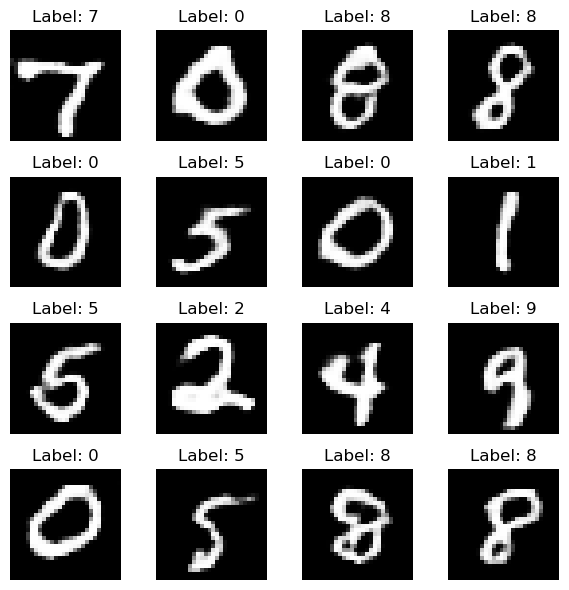

In [ ]:
import matplotlib.pyplot as plt
import torch

gen.eval()
noise = torch.randn(256, z_dim).to(device)
labels = torch.randint(0, 10, (256,)).to(device)

with torch.no_grad():
    fake_images = gen(noise, labels)

fake_images = fake_images.reshape(-1, 28, 28).cpu().detach()
fake_images = (fake_images + 1) / 2 

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_images[i], cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")



plt.tight_layout()
plt.show()

In [18]:
%load_ext tensorboard
%tensorboard --logdir logs --port 6008

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Launching TensorBoard...

In [19]:
gen_path = "mnist_cGAN_generator_final.pth"
disc_path = "mnist_cGAN_discriminator_final.pth"

torch.save(gen.state_dict(), gen_path)
torch.save(disc.state_dict(), disc_path)
